In [101]:
import opendatasets as od

In [102]:
dataset = 'https://www.kaggle.com/datasets/zagarsuren/telecom-churn-dataset-ibm-watson-analytics'

In [103]:
od.download(dataset)

Skipping, found downloaded files in ".\telecom-churn-dataset-ibm-watson-analytics" (use force=True to force download)


In [104]:
data_dir = '.\telecom-churn-dataset-ibm-watson-analytics'

In [105]:
import os

corrected_path = r"./telecom-churn-dataset-ibm-watson-analytics"

if os.path.exists(corrected_path):
    print(os.listdir(corrected_path))
else:
    print(f"Path {corrected_path} does not exist")

['telco_customer_churn.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.xlsx']


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score, recall_score, precision_score, roc_auc_score,
classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from scipy.stats import randint, uniform
warnings.filterwarnings('ignore')

In [107]:
import pandas as pd

# Load Excel file
df = pd.read_excel(
    "./telecom-churn-dataset-ibm-watson-analytics/WA_Fn-UseC_-Telco-Customer-Churn.xlsx"
)

# Save as CSV
df.to_csv(
    "./telecom-churn-dataset-ibm-watson-analytics/telco_customer_churn.csv",
    index=False
)

print("CSV file created successfully!")

CSV file created successfully!


In [134]:
df = pd.read_csv('telecom-churn-dataset-ibm-watson-analytics/telco_customer_churn.csv')

In [135]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [136]:
df.shape

(7043, 21)

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [138]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [139]:
df = df.dropna(subset=['TotalCharges'])

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [141]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [142]:
df = df.drop('customerID', axis=1)

In [143]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [144]:
object_cols = df.select_dtypes(include=['object']).columns
unique_values = {col: df[col].unique() for col in object_cols}
for col, values in unique_values.items():
    print(f"{col}: {values}")


gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [120]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

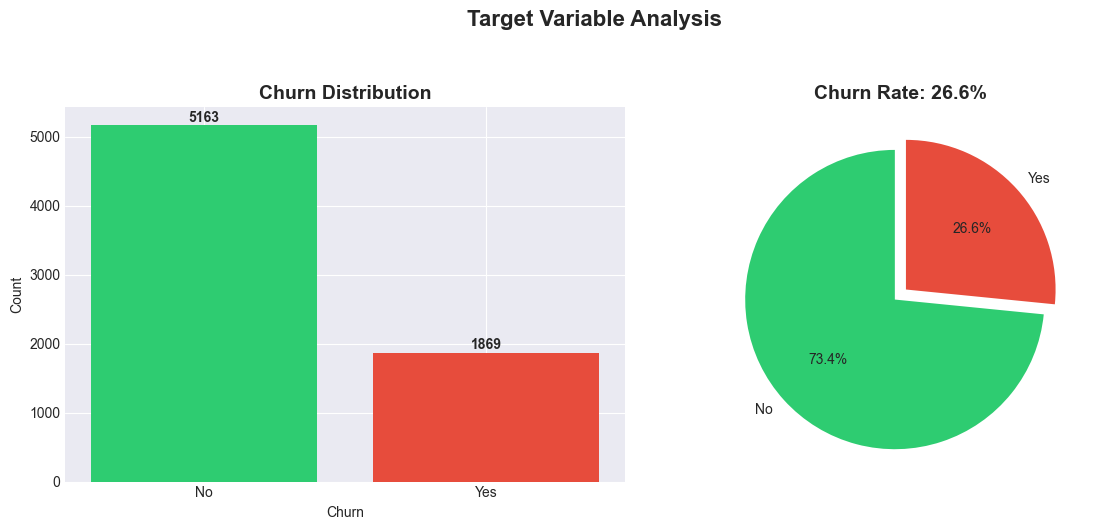

In [121]:
#TARGET VARIABLE - CLASS IMBALANCE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title(f'Churn Rate: {churn_counts["Yes"]/len(df)*100:.1f}%', 
                  fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


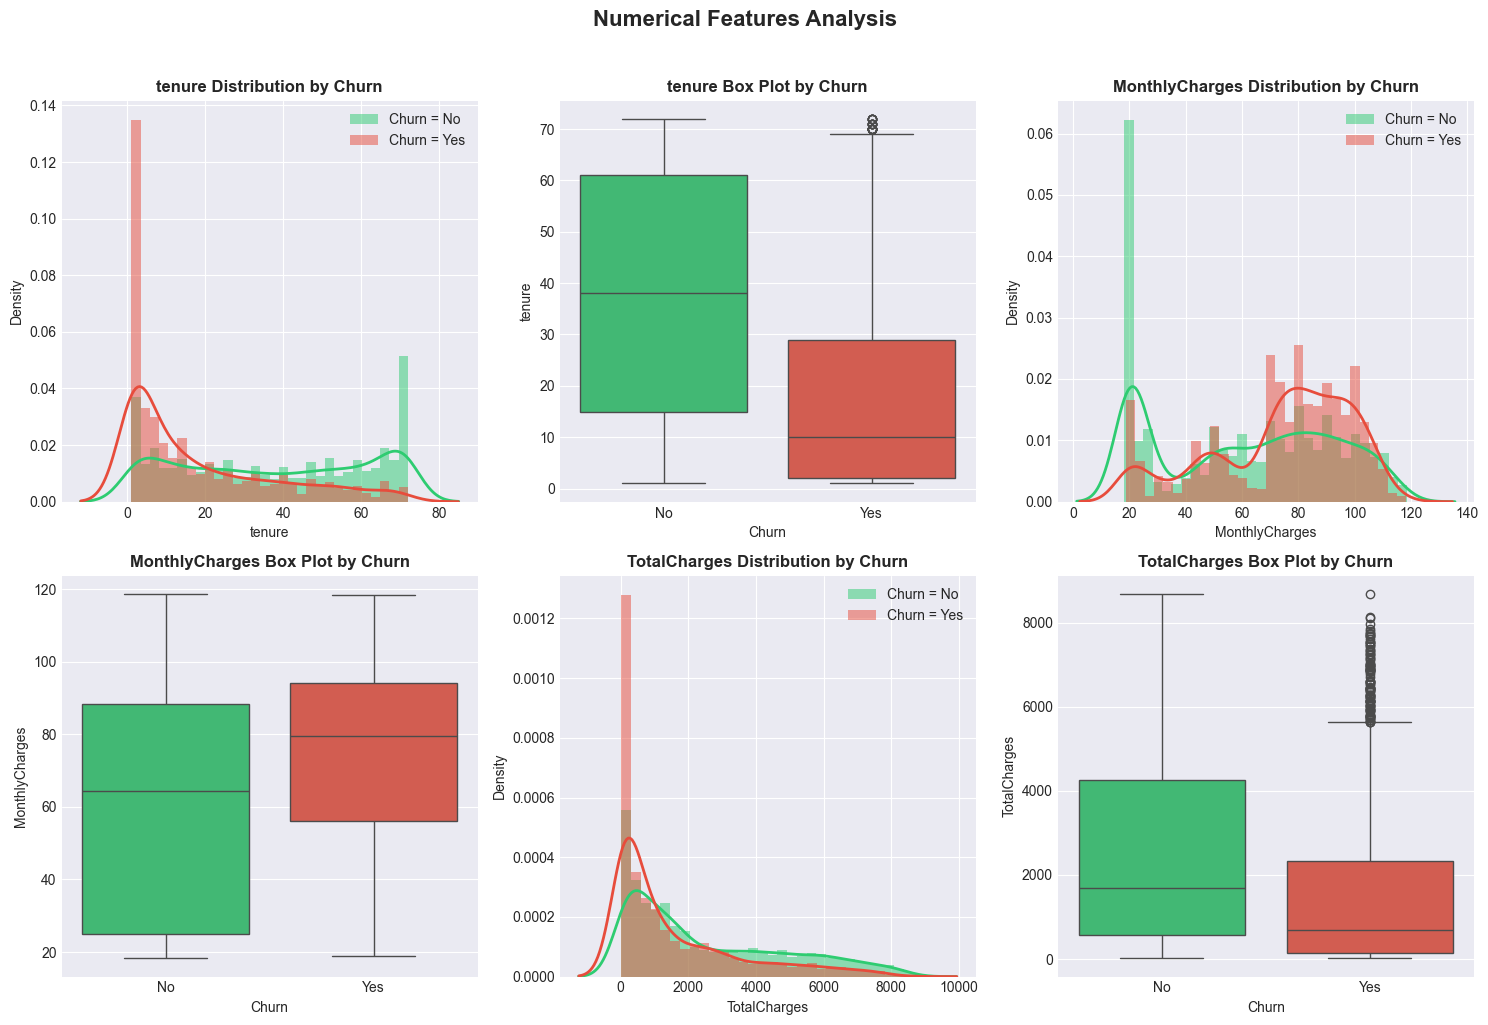

In [176]:
#NUMERICAL FEATURES - DISTRIBUTIONS BY CHURN

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    # Histogram with KDE
    for churn_val, color in zip(['No', 'Yes'], ['#2ecc71', '#e74c3c']):
        subset = df[df['Churn'] == churn_val][feature].dropna()
        axes[idx*2].hist(subset, bins=30, alpha=0.5, label=f'Churn = {churn_val}', 
                         color=color, density=True)
        sns.kdeplot(data=subset, color=color, ax=axes[idx*2], linewidth=2)
    axes[idx*2].set_title(f'{feature} Distribution by Churn', fontweight='bold')
    axes[idx*2].set_xlabel(feature)
    axes[idx*2].set_ylabel('Density')
    axes[idx*2].legend()
    
    # Box plot
    sns.boxplot(x='Churn', y=feature, data=df, ax=axes[idx*2+1], palette=['#2ecc71', '#e74c3c'])
    axes[idx*2+1].set_title(f'{feature} Box Plot by Churn', fontweight='bold')

plt.suptitle('Numerical Features Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Numerical_Features_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

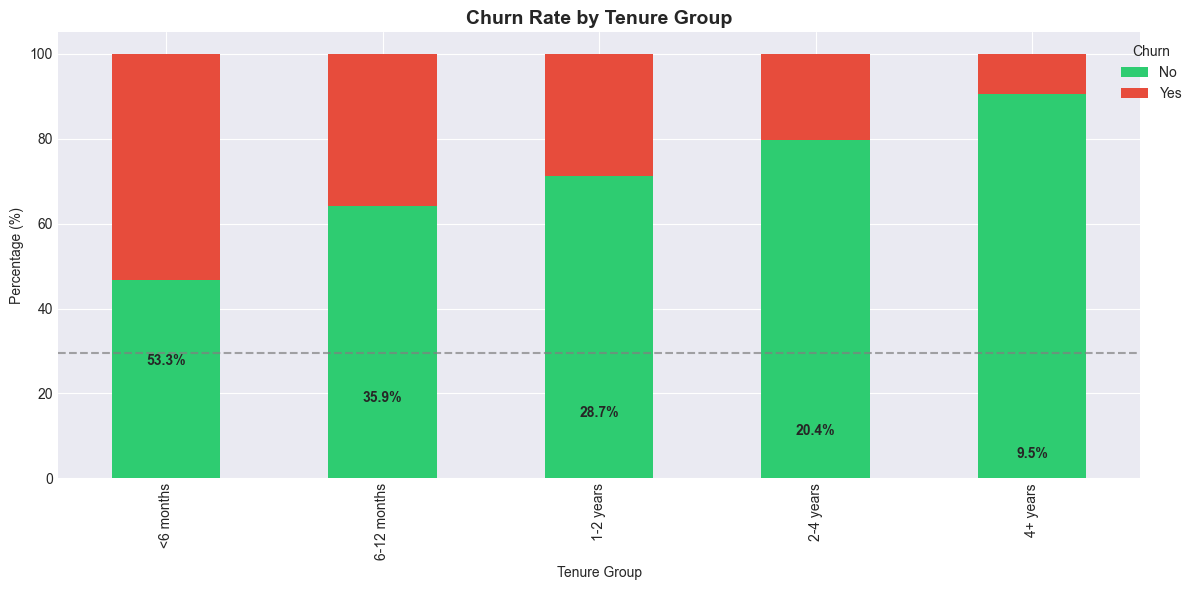

In [178]:
# TENURE SPECIFIC - BUCKETED ANALYSIS
df['TenureGroup'] = pd.cut(df['tenure'], 
                           bins=[0, 6, 12, 24, 48, 72], 
                           labels=['<6 months', '6-12 months', '1-2 years', '2-4 years', '4+ years'])

tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
tenure_churn.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Churn', bbox_to_anchor=(1.05, 1))
ax.axhline(y=tenure_churn['Yes'].mean(), linestyle='--', color='gray', alpha=0.7, label='Average Churn')

for i, (idx, row) in enumerate(tenure_churn.iterrows()):
    ax.text(i, row['Yes']/2, f"{row['Yes']:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [179]:
df['Churn_Binary'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

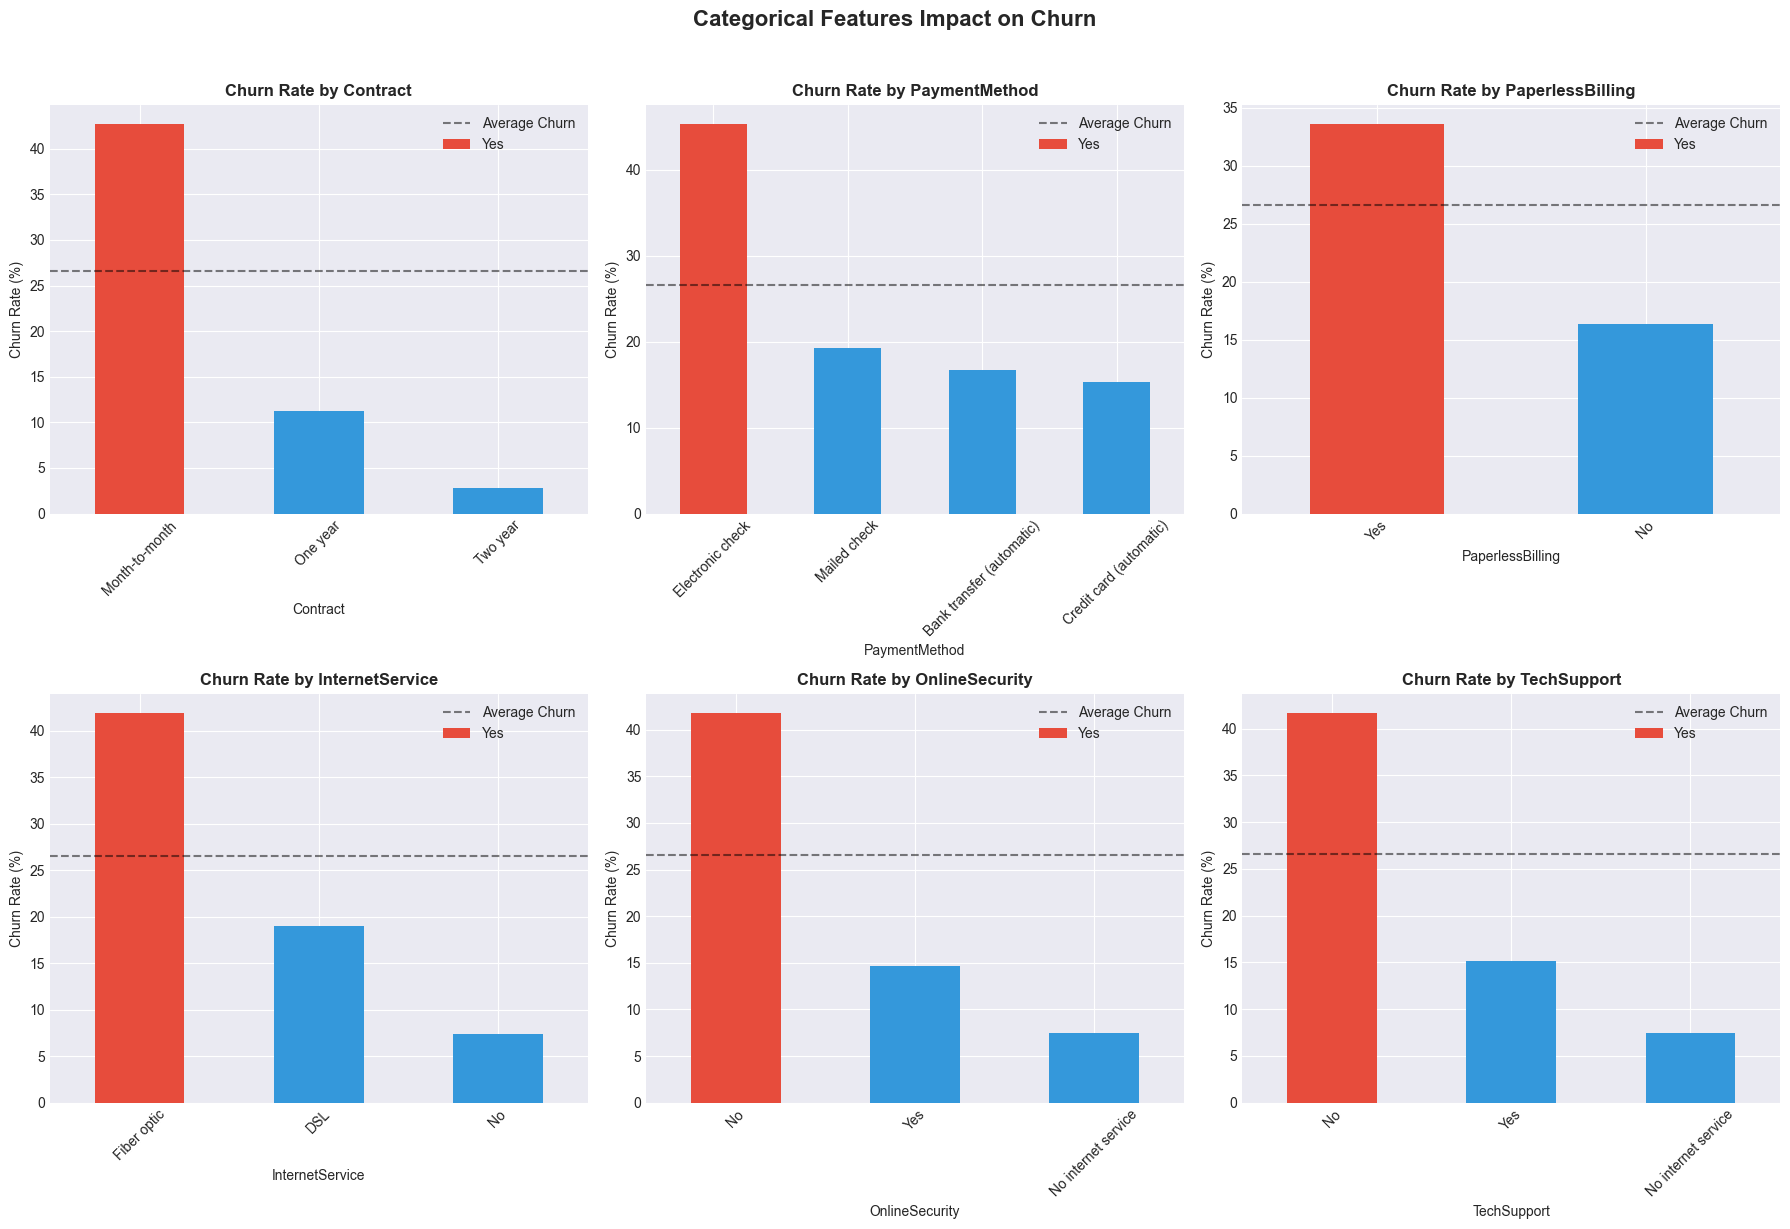

In [180]:
#CATEGORICAL FEATURES - TOP PREDICTORS
categorical_features = ['Contract', 'PaymentMethod', 'PaperlessBilling', 
                        'InternetService', 'OnlineSecurity', 'TechSupport']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    churn_rate = pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    churn_rate['Yes'].sort_values(ascending=False).plot(kind='bar', ax=axes[idx], 
                                                         color=['#e74c3c' if i == 0 else '#3498db' 
                                                                for i in range(len(churn_rate))])
    axes[idx].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].axhline(y=df['Churn_Binary'].mean()*100, linestyle='--', 
                      color='black', alpha=0.5, label='Average Churn')
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features Impact on Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Categorical_Features_Imapct.png', dpi=300, bbox_inches='tight')
plt.show()


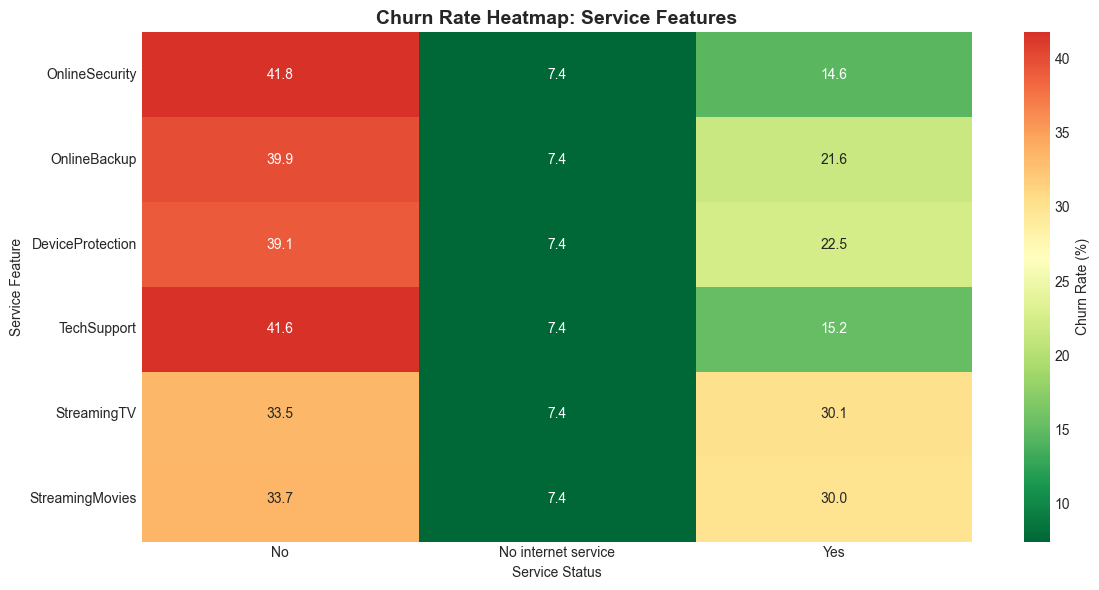

In [126]:
# SERVICE FEATURES HEATMAP
service_features = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = pd.DataFrame()
for feature in service_features:
    churn_rate = pd.crosstab(df[feature], df['Churn'], normalize='index')['Yes'] * 100
    service_churn[feature] = churn_rate

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(service_churn.T, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            center=df['Churn_Binary'].mean()*100, ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate Heatmap: Service Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Service Status')
ax.set_ylabel('Service Feature')
plt.tight_layout()
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()

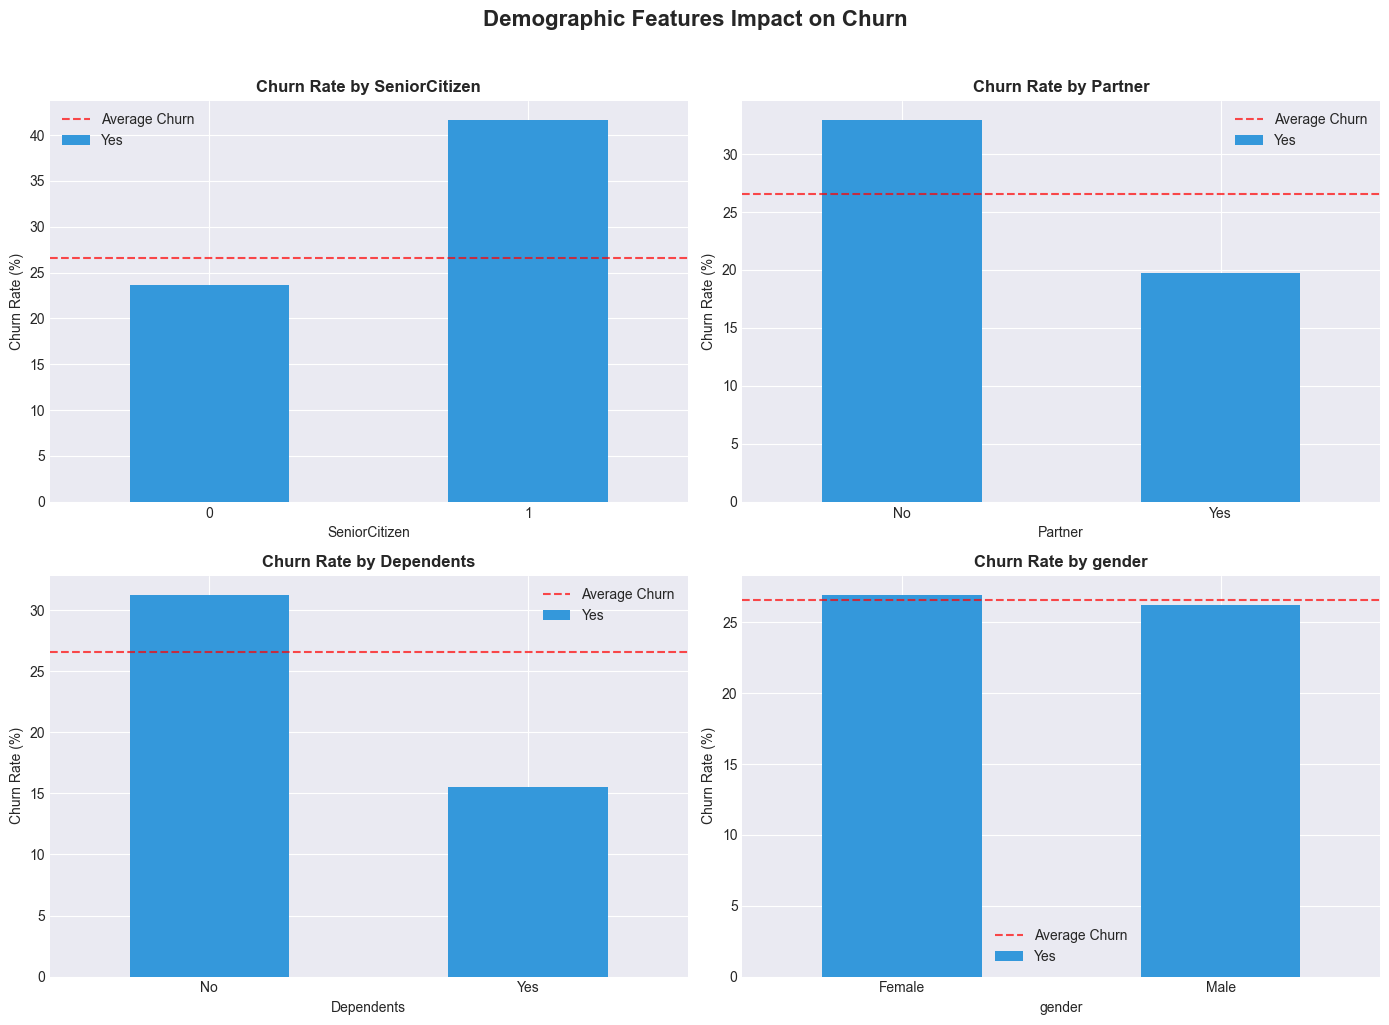

In [127]:
# DEMOGRAPHIC FEATURES
demo_features = ['SeniorCitizen', 'Partner', 'Dependents', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(demo_features):
    churn_rate = pd.crosstab(df[feature], df['Churn'], normalize='index') * 100
    churn_rate['Yes'].plot(kind='bar', ax=axes[idx], color='#3498db')
    axes[idx].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].axhline(y=df['Churn_Binary'].mean()*100, linestyle='--', 
                      color='red', alpha=0.7, label='Average Churn')
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=0)

plt.suptitle('Demographic Features Impact on Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


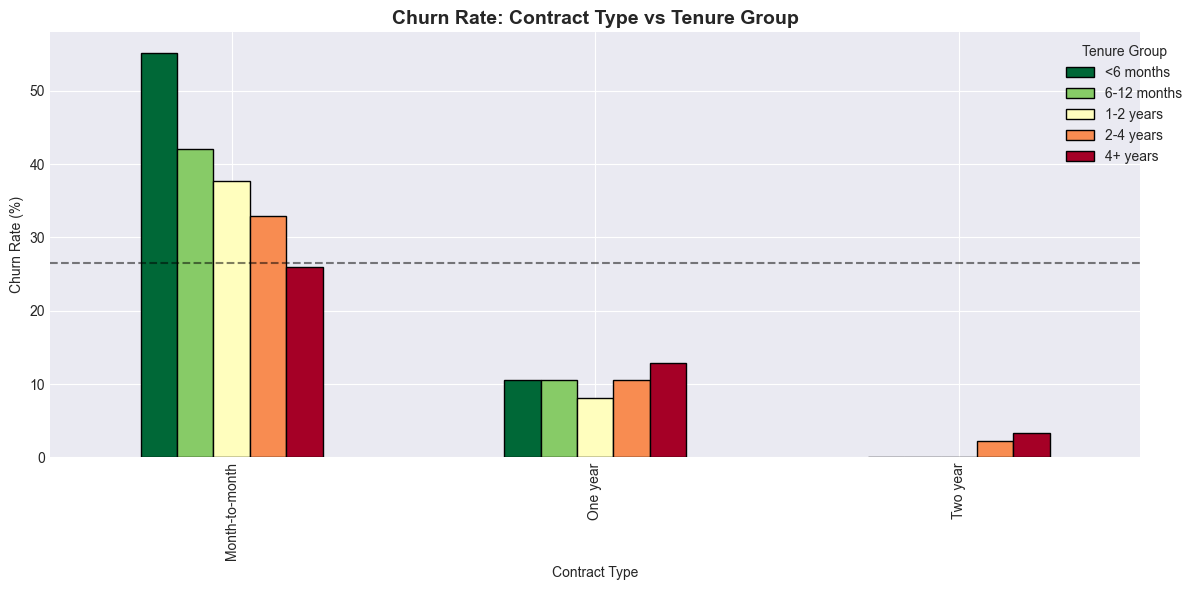

In [181]:
# CONTRACT + TENURE INTERACTION

if 'TenureGroup' not in df.columns:
    dft['TenureGroup'] = pd.cut(df['tenure'], 
                               bins=[0, 6, 12, 24, 48, 72], 
                               labels=['<6 months', '6-12 months', '1-2 years', '2-4 years', '4+ years'])

contract_tenure = df.groupby(['Contract', 'TenureGroup'])['Churn_Binary'].mean() * 100
contract_tenure = contract_tenure.unstack()

fig, ax = plt.subplots(figsize=(12, 6))
contract_tenure.plot(kind='bar', ax=ax, colormap='RdYlGn_r', edgecolor='black')
ax.set_title('Churn Rate: Contract Type vs Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.legend(title='Tenure Group', bbox_to_anchor=(1.05, 1))
ax.axhline(y=df['Churn_Binary'].mean()*100, linestyle='--', color='black', alpha=0.5)
plt.tight_layout()
plt.savefig('Eda_3.png', dpi=300, bbox_inches='tight')
plt.show()


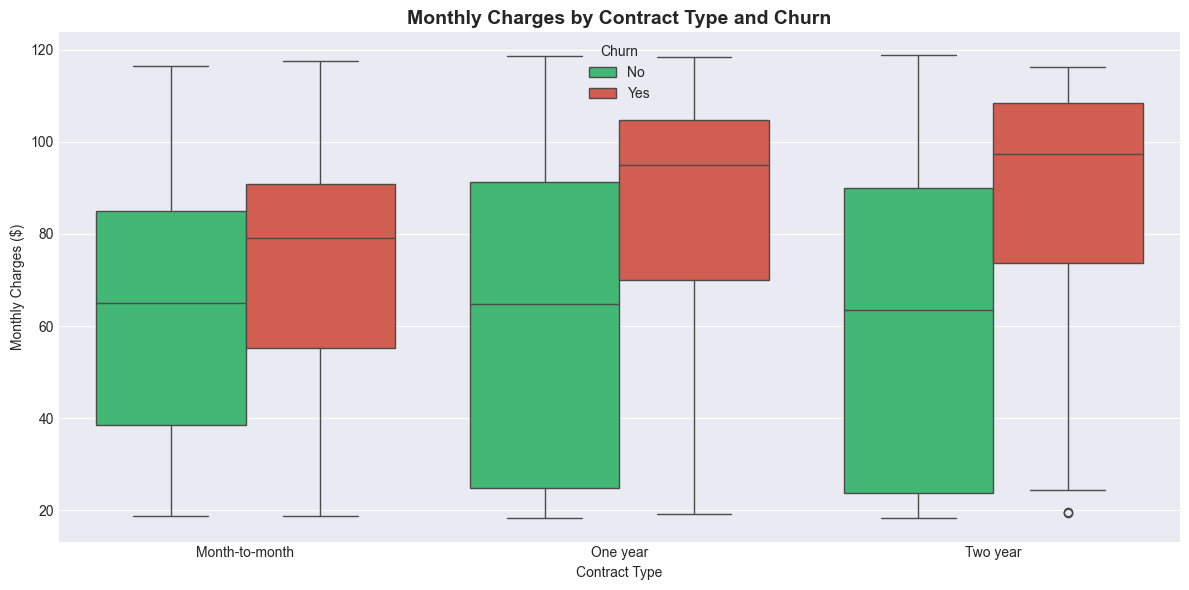

In [129]:
# MONTHLY CHARGES BY CONTRACT AND CHURN
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='Contract', y='MonthlyCharges', hue='Churn', data=df, 
            palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Monthly Charges by Contract Type and Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

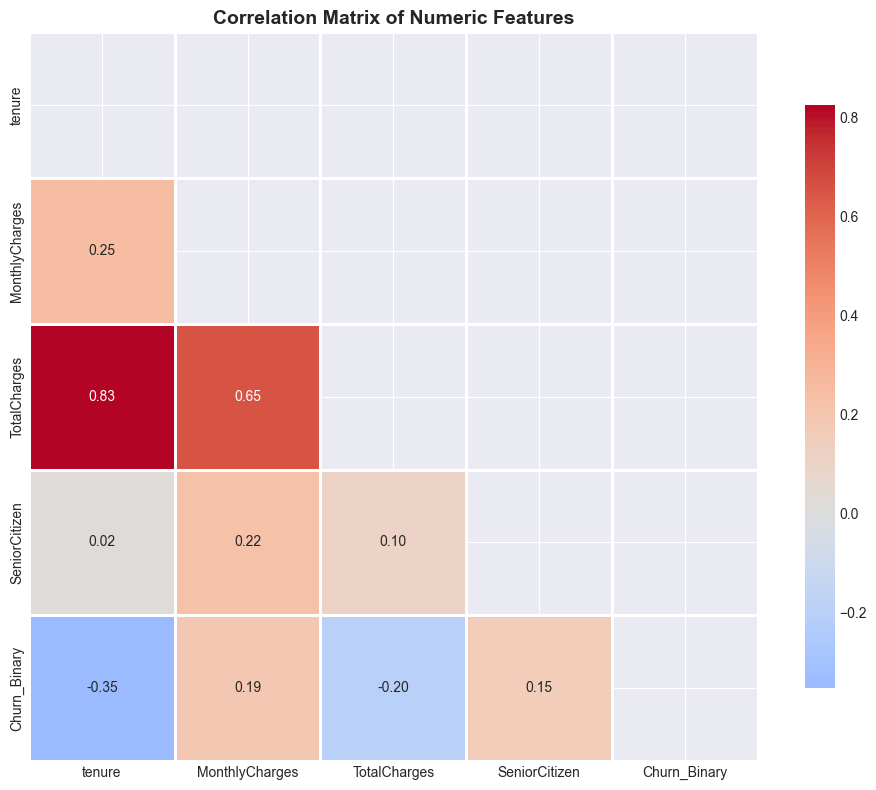

In [182]:
# CORRELATION MATRIX (NUMERIC FEATURES)
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Binary']].copy()
numeric_df = numeric_df.dropna()

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Eda_4.png', dpi=300, bbox_inches='tight')
plt.show()


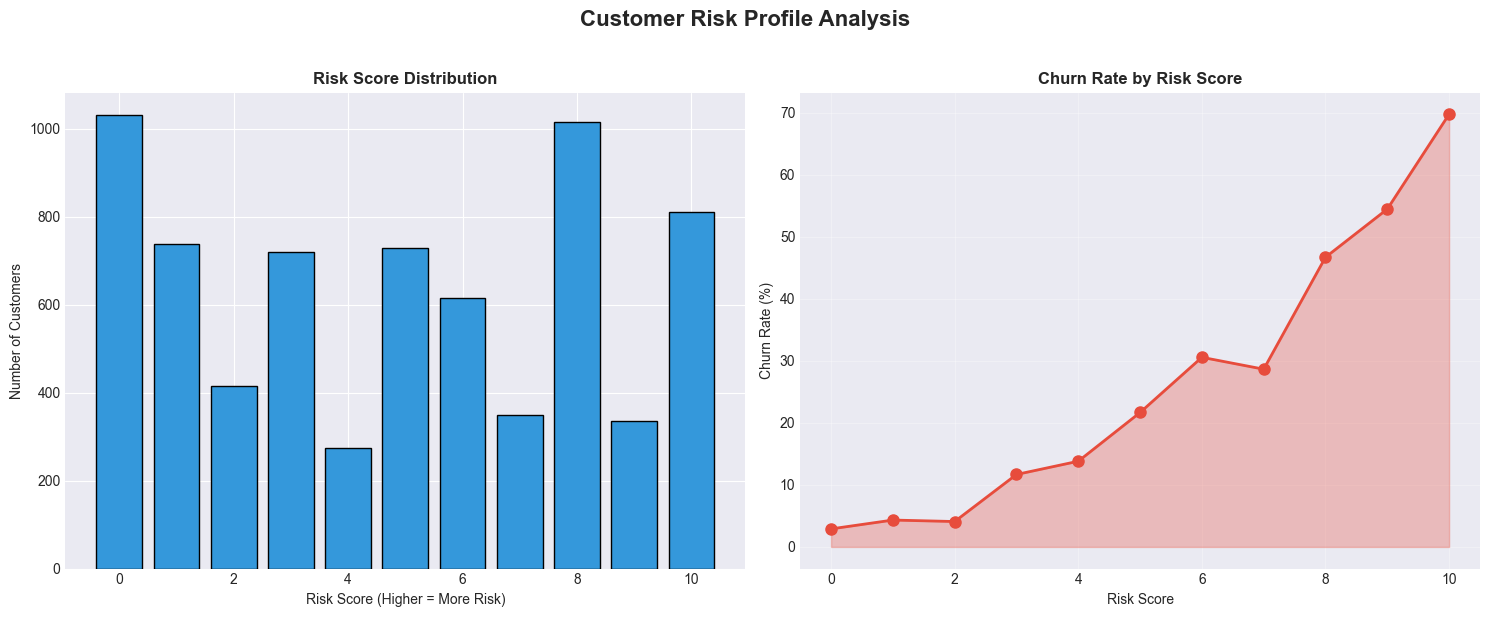

In [131]:
# MULTI-DIMENSIONAL RISK PROFILE

df['RiskScore'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 3 +
    (df['PaperlessBilling'] == 'Yes').astype(int) * 1 +
    (df['OnlineSecurity'] == 'No').astype(int) * 2 +
    (df['TechSupport'] == 'No').astype(int) * 2 +
    (df['tenure'] < 12).astype(int) * 2
)

risk_churn = df.groupby('RiskScore')['Churn_Binary'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Risk score distribution
risk_dist = df['RiskScore'].value_counts().sort_index()
axes[0].bar(risk_dist.index, risk_dist.values, color='#3498db', edgecolor='black')
axes[0].set_title('Risk Score Distribution', fontweight='bold')
axes[0].set_xlabel('Risk Score (Higher = More Risk)')
axes[0].set_ylabel('Number of Customers')

# Risk score vs churn rate
axes[1].plot(risk_churn.index, risk_churn.values, marker='o', linewidth=2, 
             markersize=8, color='#e74c3c')
axes[1].fill_between(risk_churn.index, risk_churn.values, alpha=0.3, color='#e74c3c')
axes[1].set_title('Churn Rate by Risk Score', fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Customer Risk Profile Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


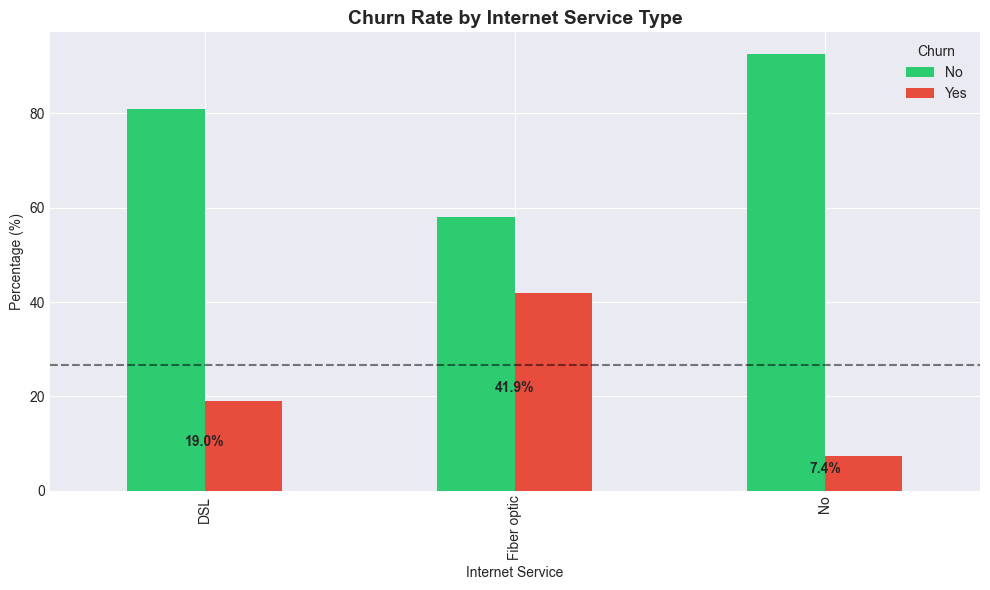

In [132]:
# ADDITIONAL: CHURN BY INTERNET SERVICE TYPE

fig, ax = plt.subplots(figsize=(10, 6))
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Churn')
ax.axhline(y=df['Churn_Binary'].mean()*100, linestyle='--', color='black', alpha=0.5, label='Average')
for i, (idx, row) in enumerate(internet_churn.iterrows()):
    ax.text(i, row['Yes']/2, f"{row['Yes']:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [133]:
# SUMMARY STATISTICS TABLE

print("\n" + "="*80)
print("KEY INSIGHTS SUMMARY".center(80))
print("="*80)

print(f"\n Overall Churn Rate: {df['Churn_Binary'].mean()*100:.1f}%")
print(f" Total Customers: {len(df):,}")
print(f" Churned Customers: {df['Churn_Binary'].sum():,}")

print("\n HIGHEST CHURN SEGMENTS:")
highest_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False)
for contract, rate in highest_churn.head(3).items():
    print(f"   • {contract}: {rate*100:.1f}% churn rate")

print("\n LOWEST CHURN SEGMENTS:")
lowest_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values()
for contract, rate in lowest_churn.head(2).items():
    print(f"   • {contract}: {rate*100:.1f}% churn rate")

print("\n TOP 5 CHURN DRIVERS:")
drivers = {
    'Month-to-month contract': df[df['Contract'] == 'Month-to-month']['Churn_Binary'].mean(),
    'No Online Security': df[df['OnlineSecurity'] == 'No']['Churn_Binary'].mean(),
    'No Tech Support': df[df['TechSupport'] == 'No']['Churn_Binary'].mean(),
    'Paperless Billing': df[df['PaperlessBilling'] == 'Yes']['Churn_Binary'].mean(),
    'Electronic check': df[df['PaymentMethod'] == 'Electronic check']['Churn_Binary'].mean(),
    'Fiber optic internet': df[df['InternetService'] == 'Fiber optic']['Churn_Binary'].mean(),
    'No device protection': df[df['DeviceProtection'] == 'No']['Churn_Binary'].mean()
}
for driver, rate in sorted(drivers.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   • {driver}: {rate*100:.1f}% churn rate")

print("\n RISK SCORE INTERPRETATION:")
print(f"   • Low Risk (Score 0-3): ~{df[df['RiskScore'] <= 3]['Churn_Binary'].mean()*100:.1f}% churn")
print(f"   • Medium Risk (Score 4-6): ~{df[(df['RiskScore'] > 3) & (df['RiskScore'] <= 6)]['Churn_Binary'].mean()*100:.1f}% churn")
print(f"   • High Risk (Score 7+): ~{df[df['RiskScore'] > 6]['Churn_Binary'].mean()*100:.1f}% churn")

print("\n" + "="*80)


                              KEY INSIGHTS SUMMARY                              

 Overall Churn Rate: 26.6%
 Total Customers: 7,032
 Churned Customers: 1,869

 HIGHEST CHURN SEGMENTS:
   • Month-to-month: 42.7% churn rate
   • One year: 11.3% churn rate
   • Two year: 2.8% churn rate

 LOWEST CHURN SEGMENTS:
   • Two year: 2.8% churn rate
   • One year: 11.3% churn rate

 TOP 5 CHURN DRIVERS:
   • Electronic check: 45.3% churn rate
   • Month-to-month contract: 42.7% churn rate
   • Fiber optic internet: 41.9% churn rate
   • No Online Security: 41.8% churn rate
   • No Tech Support: 41.6% churn rate

 RISK SCORE INTERPRETATION:
   • Low Risk (Score 0-3): ~5.6% churn
   • Medium Risk (Score 4-6): ~23.7% churn
   • High Risk (Score 7+): ~52.7% churn



In [36]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,Churn_Binary,RiskScore
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,<6 months,0,10
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,2-4 years,0,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,<6 months,1,8
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 years,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,<6 months,1,10


In [147]:

# Manual Encoding with Column Selection 
print("="*80)
print("DATA ENCODING FOR TELCO CHURN DATASET".center(80))
print("="*80)

# Creating a copy 
df_encoded = df.copy()

#Label Encoding for Binary/Multiclass Ordinal Features


print("\n Step 1: Label Encoding Applied to:")

# Binary categorical features (Yes/No)
binary_features = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Mapping for consistent encoding
binary_mapping = {'No': 0, 'Yes': 1}

for feature in binary_features:
    df_encoded[feature] = df_encoded[feature].map(binary_mapping)
    print(f"   • {feature}: No=0, Yes=1")

# Gender (Male/Female)
df_encoded['gender'] = df_encoded['gender'].map({'Female': 0, 'Male': 1})
print(f"   • gender: Female=0, Male=1")

# SeniorCitizen already 0/1
print(f"   • SeniorCitizen: Already binary (0/1)")

# MultipleLines (has 'No phone service' which is same as 'No' for encoding)
multiple_lines_map = {
    'No': 0,
    'No phone service': 0,
    'Yes': 1
}
df_encoded['MultipleLines'] = df_encoded['MultipleLines'].map(multiple_lines_map)
print(f"   • MultipleLines: No/No phone service=0, Yes=1")

# InternetService (Ordinal: None < DSL < Fiber optic)
internet_map = {
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
}
df_encoded['InternetService'] = df_encoded['InternetService'].map(internet_map)
print(f"   • InternetService: No=0, DSL=1, Fiber optic=2")

# Contract (Ordinal: Month-to-month < One year < Two year)
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}
df_encoded['Contract'] = df_encoded['Contract'].map(contract_map)
print(f"   • Contract: Month-to-month=0, One year=1, Two year=2")


# One-Hot Encoding for Nominal Categorical Features


print("\n Step 2: One-Hot Encoding Applied to:")

# Features that need One-Hot Encoding (no ordinal relationship)
nominal_features = ['PaymentMethod', 'OnlineSecurity', 'OnlineBackup', 
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Create dummy variables (dropping first to avoid multicollinearity)
for feature in nominal_features:
    dummies = pd.get_dummies(df_encoded[feature], prefix=feature, drop_first=True)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    df_encoded.drop(feature, axis=1, inplace=True)
    print(f"   • {feature}: Created {dummies.shape[1]} dummy variables")

# Target Variable Encoding
print("\n Step 3: Target Variable Encoding:")
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})
print(f"   • Churn: No=0, Yes=1")




                     DATA ENCODING FOR TELCO CHURN DATASET                      

 Step 1: Label Encoding Applied to:
   • Partner: No=0, Yes=1
   • Dependents: No=0, Yes=1
   • PhoneService: No=0, Yes=1
   • PaperlessBilling: No=0, Yes=1
   • gender: Female=0, Male=1
   • SeniorCitizen: Already binary (0/1)
   • MultipleLines: No/No phone service=0, Yes=1
   • InternetService: No=0, DSL=1, Fiber optic=2
   • Contract: Month-to-month=0, One year=1, Two year=2

 Step 2: One-Hot Encoding Applied to:
   • PaymentMethod: Created 3 dummy variables
   • OnlineSecurity: Created 2 dummy variables
   • OnlineBackup: Created 2 dummy variables
   • DeviceProtection: Created 2 dummy variables
   • TechSupport: Created 2 dummy variables
   • StreamingTV: Created 2 dummy variables
   • StreamingMovies: Created 2 dummy variables

 Step 3: Target Variable Encoding:
   • Churn: No=0, Yes=1


In [148]:
df_encoded.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,0,1,0,1,...,False,True,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,0,1,1,0,...,False,False,False,True,False,False,False,False,False,False


In [149]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   InternetService                        7032 non-null   int64  
 8   Contract                               7032 non-null   int64  
 9   PaperlessBilling                       7032 non-null   int64  
 10  MonthlyCharges                         7032 non-null   float64
 11  TotalChar

In [150]:
plt.style.use('seaborn-v0_8-darkgrid')

In [151]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [152]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [153]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])


In [154]:
# CALCULATING IMBALANCE PARAMETERS

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count


In [164]:
#XGBOOST MODEL WITH HYPERPARAMETER TUNING


print("XGBOOST MODEL TRAINING")
print("=" * 50)

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

xgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("Training XGBoost...")
xgb_search.fit(X_train_scaled, y_train)
xgb_best = xgb_search.best_estimator_

print(f"Best CV F1 Score: {xgb_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in xgb_search.best_params_.items():
    print(f"  {param}: {value}")
print("-" * 50)


# RANDOM FOREST MODEL WITH HYPERPARAMETER TUNING


print("RANDOM FOREST MODEL TRAINING")
print("=" * 50)

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("Training Random Forest...")
rf_search.fit(X_train_scaled, y_train)
rf_best = rf_search.best_estimator_

print(f"Best CV F1 Score: {rf_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")
print("-" * 50)



# LIGHTGBM MODEL WITH HYPERPARAMETER TUNING


print("LIGHTGBM MODEL TRAINING")
print("=" * 50)

lgb_model = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'learning_rate': [0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    lgb_model,
    param_distributions=lgb_param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("Training LightGBM...")
lgb_search.fit(X_train_scaled, y_train)
lgb_best = lgb_search.best_estimator_

print(f"Best CV F1 Score: {lgb_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in lgb_search.best_params_.items():
    print(f"  {param}: {value}")
print("-" * 50)


XGBOOST MODEL TRAINING
Training XGBoost...
Best CV F1 Score: 0.6412
Best Parameters:
  subsample: 0.8
  n_estimators: 100
  min_child_weight: 3
  max_depth: 5
  learning_rate: 0.05
  colsample_bytree: 0.8
--------------------------------------------------
RANDOM FOREST MODEL TRAINING
Training Random Forest...
Best CV F1 Score: 0.6373
Best Parameters:
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 2
  max_features: sqrt
  max_depth: 10
--------------------------------------------------
LIGHTGBM MODEL TRAINING
Training LightGBM...
Best CV F1 Score: 0.6358
Best Parameters:
  subsample: 1.0
  num_leaves: 31
  n_estimators: 100
  max_depth: 5
  learning_rate: 0.05
  colsample_bytree: 1.0
--------------------------------------------------


In [165]:
# MAKING PREDICTIONS

print("MODEL PREDICTIONS")
print("=" * 50)

y_pred_proba_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = (y_pred_proba_xgb >= 0.5).astype(int)

y_pred_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = (y_pred_proba_rf >= 0.5).astype(int)

y_pred_proba_lgb = lgb_best.predict_proba(X_test_scaled)[:, 1]
y_pred_lgb = (y_pred_proba_lgb >= 0.5).astype(int)

print("Predictions generated for all models")
print("-" * 50)

MODEL PREDICTIONS
Predictions generated for all models
--------------------------------------------------


In [166]:
# THRESHOLD OPTIMIZATION

def find_optimal_threshold(y_true, y_proba):
    thresholds = np.arange(0.1, 0.9, 0.05)
    f1_scores = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        f1_scores.append(f1_score(y_true, y_pred))
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

xgb_threshold, xgb_best_f1 = find_optimal_threshold(y_test, y_pred_proba_xgb)
rf_threshold, rf_best_f1 = find_optimal_threshold(y_test, y_pred_proba_rf)
lgb_threshold, lgb_best_f1 = find_optimal_threshold(y_test, y_pred_proba_lgb)

print(f"XGBoost optimal threshold: {xgb_threshold:.2f} (F1: {xgb_best_f1:.4f})")
print(f"Random Forest optimal threshold: {rf_threshold:.2f} (F1: {rf_best_f1:.4f})")
print(f"LightGBM optimal threshold: {lgb_threshold:.2f} (F1: {lgb_best_f1:.4f})")

y_pred_xgb_opt = (y_pred_proba_xgb >= xgb_threshold).astype(int)
y_pred_rf_opt = (y_pred_proba_rf >= rf_threshold).astype(int)
y_pred_lgb_opt = (y_pred_proba_lgb >= lgb_threshold).astype(int)
print("-" * 50)


XGBoost optimal threshold: 0.55 (F1: 0.6325)
Random Forest optimal threshold: 0.50 (F1: 0.6329)
LightGBM optimal threshold: 0.60 (F1: 0.6321)
--------------------------------------------------


In [167]:
# CALCULATE PERFORMANCE METRICS

print("PERFORMANCE METRICS")
print("=" * 50)

results = []

for name, y_pred, y_proba, threshold in [
    ('XGBoost', y_pred_xgb_opt, y_pred_proba_xgb, xgb_threshold),
    ('Random Forest', y_pred_rf_opt, y_pred_proba_rf, rf_threshold),
    ('LightGBM', y_pred_lgb_opt, y_pred_proba_lgb, lgb_threshold)
]:
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    results.append({
        'Model': name,
        'Threshold': threshold,
        'F1 Score': f1,
        'Recall': recall,
        'Precision': precision,
        'ROC-AUC': roc_auc,
        'Avg Precision': avg_precision,
        'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("-" * 50)


PERFORMANCE METRICS
        Model  Threshold  F1 Score   Recall  Precision  ROC-AUC  Avg Precision  TP  FN  FP  TN
      XGBoost       0.55  0.632497 0.775401   0.534070 0.837813       0.648864 290  84 253 780
Random Forest       0.50  0.632883 0.751337   0.546693 0.836092       0.640930 281  93 233 800
     LightGBM       0.60  0.632075 0.716578   0.565401 0.837872       0.649333 268 106 206 827
--------------------------------------------------


In [175]:
# SELECTING BEST MODEL

best_model_row = results_df.loc[results_df['F1 Score'].idxmax()]
best_model_name = best_model_row['Model']

print(f"Best Model: {best_model_name}")
print(f"F1 Score: {best_model_row['F1 Score']:.4f}")
print(f"Recall: {best_model_row['Recall']:.4f}")
print(f"Precision: {best_model_row['Precision']:.4f}")
print(f"ROC-AUC: {best_model_row['ROC-AUC']:.4f}")
print(f"Optimal Threshold: {best_model_row['Threshold']:.2f}")

if best_model_name == 'XGBoost':
    final_model = xgb_best
    final_threshold = xgb_threshold
elif best_model_name == 'Random Forest':
    final_model = rf_best
    final_threshold = rf_threshold
else:
    final_model = lgb_best
    final_threshold = lgb_threshold

Best Model: Random Forest
F1 Score: 0.6329
Recall: 0.7513
Precision: 0.5467
ROC-AUC: 0.8361
Optimal Threshold: 0.50


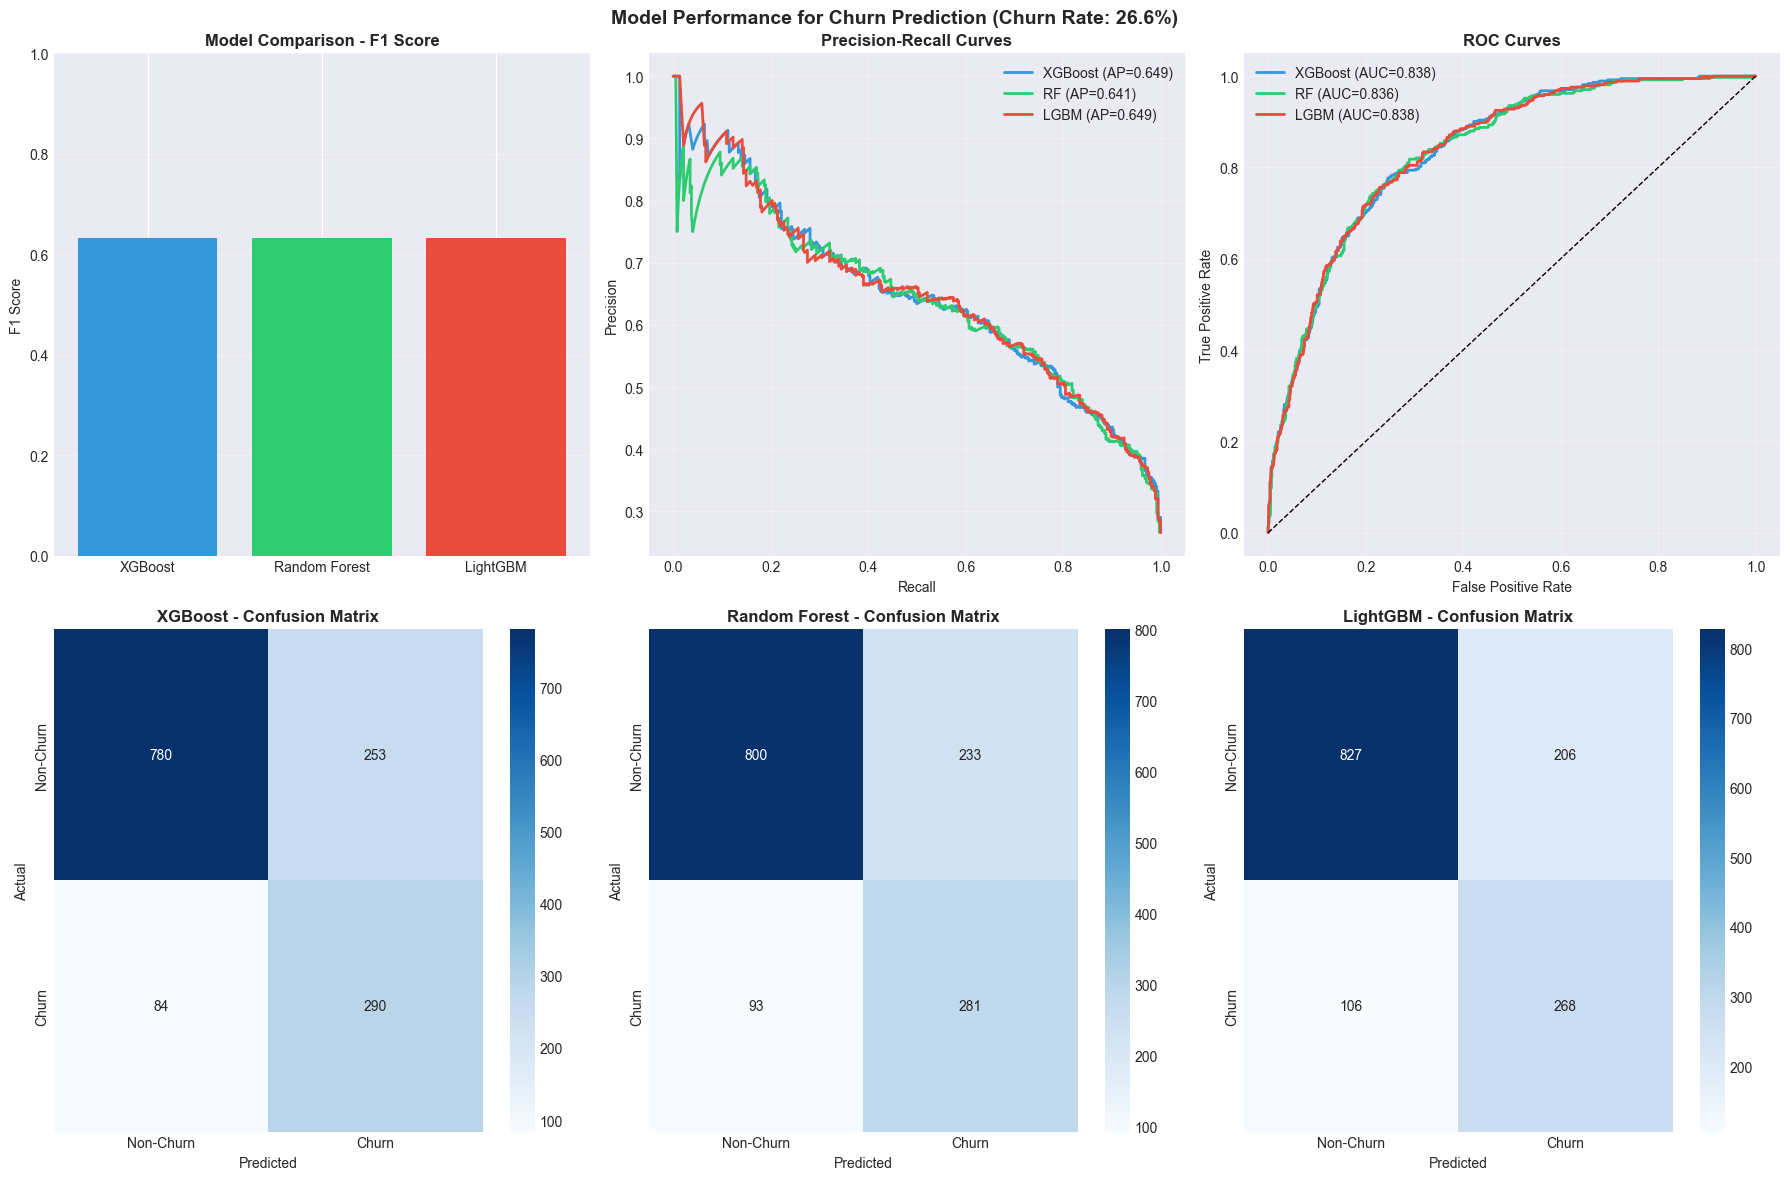

In [169]:
# VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0,0].bar(results_df['Model'], results_df['F1 Score'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0,0].set_ylim([0, 1])
axes[0,0].set_ylabel('F1 Score')
axes[0,0].set_title('Model Comparison - F1 Score', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, axis='y')

models = [(xgb_best, 'XGBoost'), (rf_best, 'RF'), (lgb_best, 'LGBM')]
colors = ['#3498db', '#2ecc71', '#e74c3c']
for (model, name), color in zip(models, colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[0,1].plot(recall, precision, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision-Recall Curves', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

for (model, name), color in zip(models, colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0,2].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
axes[0,2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curves', fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

for idx, (name, y_pred) in enumerate([
    ('XGBoost', y_pred_xgb_opt),
    ('Random Forest', y_pred_rf_opt),
    ('LightGBM', y_pred_lgb_opt)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, idx],
                xticklabels=['Non-Churn', 'Churn'],
                yticklabels=['Non-Churn', 'Churn'])
    axes[1, idx].set_title(f'{name} - Confusion Matrix', fontweight='bold')
    axes[1, idx].set_xlabel('Predicted')
    axes[1, idx].set_ylabel('Actual')

churn_rate = float(y_test.mean() * 100)

plt.suptitle(
    f'Model Performance for Churn Prediction (Churn Rate: {churn_rate:.1f}%)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Top 10 Features (Random Forest):
                        feature  importance
                         tenure    0.173379
                       Contract    0.171926
                   TotalCharges    0.136591
                 MonthlyCharges    0.102765
                InternetService    0.066751
 PaymentMethod_Electronic check    0.053071
             OnlineSecurity_Yes    0.030690
                TechSupport_Yes    0.025338
StreamingTV_No internet service    0.020376
               PaperlessBilling    0.018158


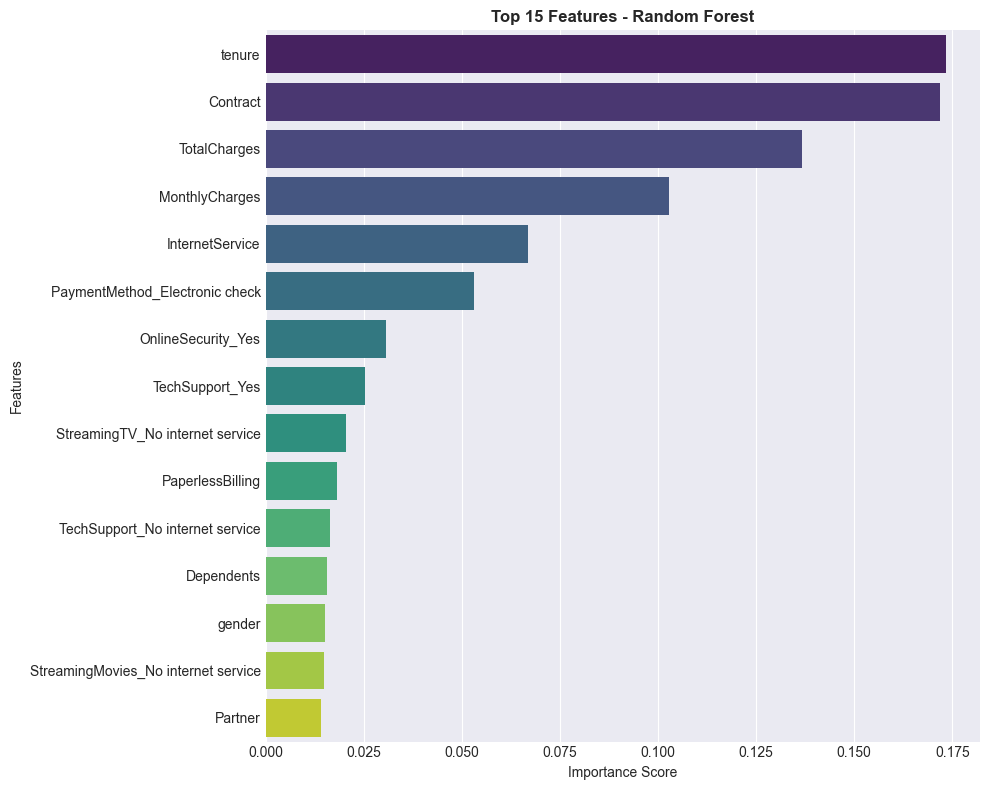

In [174]:
#  FEATURE IMPORTANCE ANALYSIS

if best_model_name == 'XGBoost':
    importances = final_model.feature_importances_
elif best_model_name == 'Random Forest':
    importances = final_model.feature_importances_
else:
    importances = final_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(f"Top 10 Features ({best_model_name}):")
print(feature_importance.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis', ax=ax)
ax.set_title(f'Top 15 Features - {best_model_name}', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Features')
plt.tight_layout()
plt.show()

In [173]:
# SAVING MODEL AND ARTIFACTS

joblib.dump(final_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(final_threshold, 'optimal_threshold.pkl')

metadata = {
    'model_name': best_model_name,
    'threshold': final_threshold,
    'f1_score': best_model_row['F1 Score'],
    'recall': best_model_row['Recall'],
    'precision': best_model_row['Precision'],
    'features': list(X.columns),
    'numeric_features': numeric_features,
    'imbalance_ratio': scale_pos_weight,
    'churn_rate': churn_rate
}
joblib.dump(metadata, 'model_metadata.pkl')

print("Files saved:")
print("  - best_churn_model.pkl")
print("  - scaler.pkl")
print("  - optimal_threshold.pkl")
print("  - model_metadata.pkl")

Files saved:
  - best_churn_model.pkl
  - scaler.pkl
  - optimal_threshold.pkl
  - model_metadata.pkl
